### 1. Импорты и пути

In [23]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

BASE_DIR = Path("../outputs")
RESULTS_DIR = BASE_DIR / "results"
TRACES_DIR = BASE_DIR / "traces"

### 2. Загрузка основных файлов

In [24]:
summary = pd.read_csv(RESULTS_DIR / "summary.csv")

baseline_records = pd.read_csv(RESULTS_DIR / "baseline_records.csv")
agent_records = pd.read_csv(RESULTS_DIR / "agent_records.csv")
agent_evaluator_records = pd.read_csv(RESULTS_DIR / "agent_evaluator_records.csv")

topk_experiment = pd.read_csv(RESULTS_DIR / "topk_experiment.csv")
max_steps_experiment = pd.read_csv(RESULTS_DIR / "max_steps_experiment.csv")

### 3. Сводная таблица

In [25]:
summary_rounded = summary.copy()
num_cols = summary_rounded.select_dtypes(include="number").columns
summary_rounded[num_cols] = summary_rounded[num_cols].round(3)

summary_rounded

,mode,correctness,groundedness,completeness,coverage,source_consistency,rubric,n_steps,n_sources,latency
0,agent,0.375,0.50,0.125,0.250,0.625,0.375,4.000,8.0,15.542
1,agent_evaluator,1.000,1.25,0.625,0.875,1.250,1.000,5.875,8.0,48.670
2,baseline,1.125,0.00,0.500,0.750,0.000,0.475,3.000,0.0,15.626


### 4. Таблица сравнения по темам 

In [26]:
main_records = pd.concat(
    [baseline_records, agent_records, agent_evaluator_records],
    ignore_index=True
)

topic_comparison = (
    main_records
    .pivot_table(index="topic", columns="mode", values="rubric")
    .round(3)
)

topic_comparison

mode,agent,agent_evaluator,baseline
topic,,,
Agentic AI for customer support,0.0,3.2,1.4
Graph RAG for enterprise knowledge systems,0.0,0.0,0.0
Human-in-the-loop AI systems,0.0,0.0,0.0
Knowledge graphs for procedural reasoning,0.0,0.0,0.0
LLM evaluation and process-aware metrics,0.0,4.8,0.0
Planning and reflection in LLM agents,3.0,0.0,0.0
Retrieval-augmented generation in medicine,0.0,0.0,2.4
Tool-using language models in scientific search,0.0,0.0,0.0


### 5. Основной график качества результата

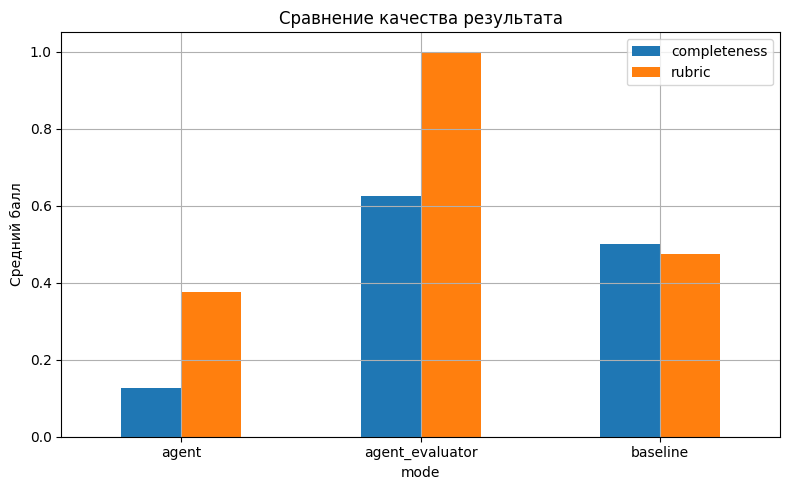

In [27]:
quality_cols = ["completeness", "rubric"]

summary.set_index("mode")[quality_cols].plot(kind="bar", figsize=(8, 5))
plt.title("Сравнение качества результата")
plt.ylabel("Средний балл")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 6. Основной график качества процесса

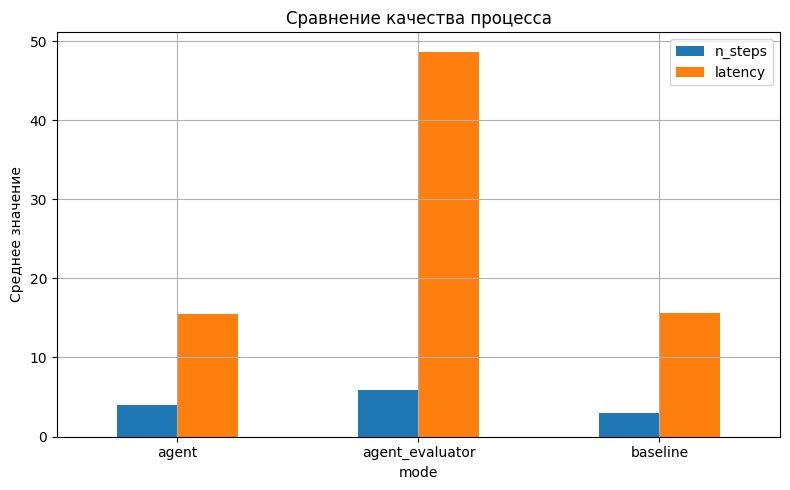

In [28]:
process_cols = ["n_steps", "latency"]

summary.set_index("mode")[process_cols].plot(kind="bar", figsize=(8, 5))
plt.title("Сравнение качества процесса")
plt.ylabel("Среднее значение")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 7. Таблица для вывода по main experiment

In [29]:
main_table = summary[[
    "mode",
    "completeness",
    "rubric",
    "n_steps",
    "latency"
]].copy()

main_table = main_table.round(3)
main_table

,mode,completeness,rubric,n_steps,latency
0,agent,0.125,0.375,4.000,15.542
1,agent_evaluator,0.625,1.000,5.875,48.670
2,baseline,0.500,0.475,3.000,15.626


### 8. Факторный эксперимент: влияние top_k

In [30]:
topk_summary = (
    topk_experiment
    .groupby("top_k")[["rubric", "latency"]]
    .mean()
    .round(3)
)

topk_summary

,rubric,latency
top_k,,
3,0.0,11.055
5,0.7,14.812
8,0.4,21.862


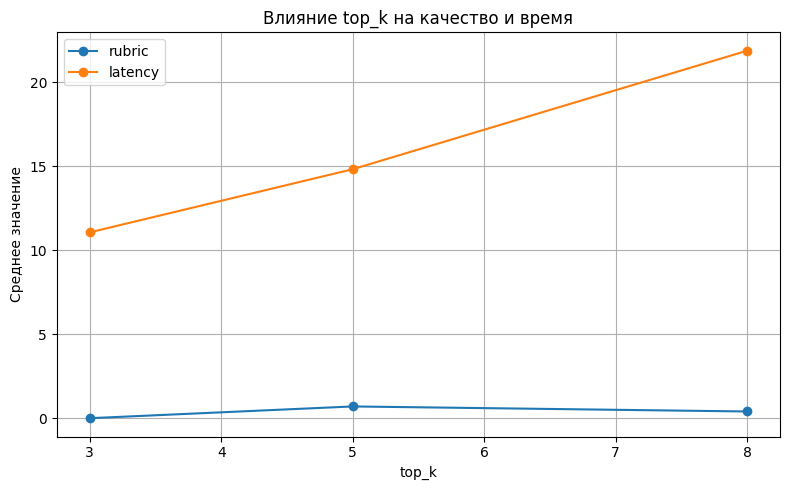

In [31]:
topk_summary.plot(marker="o", figsize=(8, 5))
plt.title("Влияние top_k на качество и время")
plt.xlabel("top_k")
plt.ylabel("Среднее значение")
plt.tight_layout()
plt.show()

### 9. Факторный эксперимент: влияние max_steps

In [32]:
steps_summary = (
    max_steps_experiment
    .groupby("max_steps")[["rubric", "latency"]]
    .mean()
    .round(3)
)

steps_summary

,rubric,latency
max_steps,,
4,0.800,16.507
6,1.975,21.145
8,0.000,13.295


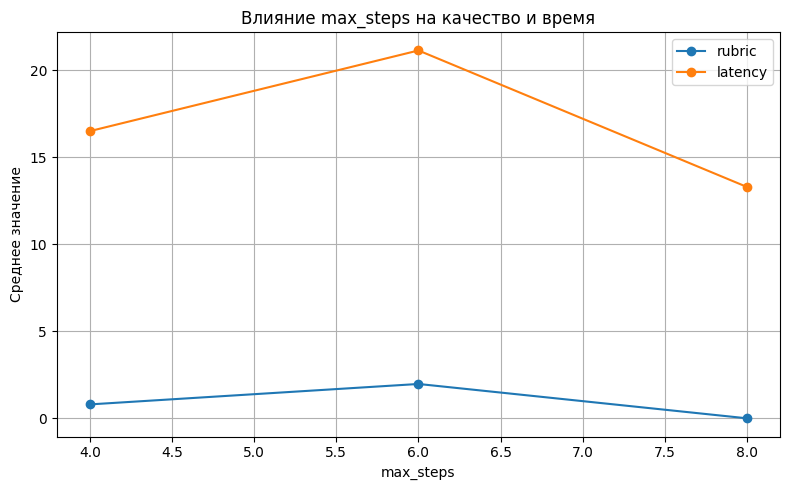

In [33]:
steps_summary.plot(marker="o", figsize=(8, 5))
plt.title("Влияние max_steps на качество и время")
plt.xlabel("max_steps")
plt.ylabel("Среднее значение")
plt.tight_layout()
plt.show()

### 10. Вывод по основным режимам

In [34]:
s = summary.set_index("mode")

best_mode = s["rubric"].idxmax()
fastest_mode = s["latency"].idxmin()
fewest_steps_mode = s["n_steps"].idxmin()

print("Основные выводы:")
print(f"Лучший режим по rubric: {best_mode} ({s.loc[best_mode, 'rubric']:.3f})")
print(f"Самый быстрый режим: {fastest_mode} ({s.loc[fastest_mode, 'latency']:.3f} сек)")
print(f"Минимум шагов: {fewest_steps_mode} ({s.loc[fewest_steps_mode, 'n_steps']:.3f})")

print("\nРазница agent_evaluator vs agent:")
print(f"rubric:   {s.loc['agent_evaluator', 'rubric'] - s.loc['agent', 'rubric']:.3f}")
print(f"latency:  {s.loc['agent_evaluator', 'latency'] - s.loc['agent', 'latency']:.3f}")
print(f"n_steps:  {s.loc['agent_evaluator', 'n_steps'] - s.loc['agent', 'n_steps']:.3f}")

Основные выводы:
Лучший режим по rubric: agent_evaluator (1.000)
Самый быстрый режим: agent (15.542 сек)
Минимум шагов: baseline (3.000)

Разница agent_evaluator vs agent:
rubric:   0.625
latency:  33.128
n_steps:  1.875
